## Date Fruit Dataset - Machine Learning Classification


This notebook uses the Date Fruit Dataset to build ML models that predict the type of date fruit based on numerical features.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muratkokludataset/date-fruit-datasets")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\janah\.cache\kagglehub\datasets\muratkokludataset\date-fruit-datasets\versions\1


In [4]:
import os
os.listdir(path)

['Date_Fruit_Datasets']

In [5]:
inner_path = path + '/Date_Fruit_Datasets'
os.listdir(inner_path)

['Date_Fruit_Datasets.arff',
 'Date_Fruit_Datasets.xlsx',
 'Date_Fruit_Datasets_Citation_Request.txt']

In [5]:
!python -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/44/3c/d717024885424591d5376220b5e836c2d5293ce2011523c9de23ff7bf068/pip-25.3-py3-none-any.whl.metadata
  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
!python -m pip install --upgrade numpy pandas openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 4.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 20.7 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 18.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]
   ---------------------------------------- 0/2 [openpyxl]

# Load the Date Fruit Dataset


In [6]:
import pandas as pd


file_path = inner_path + '/Date_Fruit_Datasets.xlsx'

df = pd.read_excel(file_path)
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [7]:
missing_values = df.isnull().sum()
print("=== Missing Values in Each Column ===")
print(missing_values)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

categorical_cols = ['Class']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


=== Missing Values in Each Column ===
AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
MeanRR           0
MeanRG           0
MeanRB           0
StdDevRR         0
StdDevRG         0
StdDevRB         0
SkewRR           0
SkewRG           0
SkewRB           0
KurtosisRR       0
KurtosisRG       0
KurtosisRB       0
EntropyRR        0
EntropyRG        0
EntropyRB        0
ALLdaub4RR       0
ALLdaub4RG       0
ALLdaub4RB       0
Class            0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])  
print("Classes mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Classes mapping: {'BERHI': 0, 'DEGLET': 1, 'DOKOL': 2, 'IRAQI': 3, 'ROTANA': 4, 'SAFAVI': 5, 'SOGAY': 6}


In [9]:

TARGET = 'Class'


FEATURE_COLS = [col for col in df.columns if col != TARGET]

X = df[FEATURE_COLS]
y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (898, 34)
Target shape: (898,)


# Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (718, 34) (718,)
Test set: (180, 34) (180,)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Baseline (Most Frequent)": DummyClassifier(strategy="most_frequent")
}


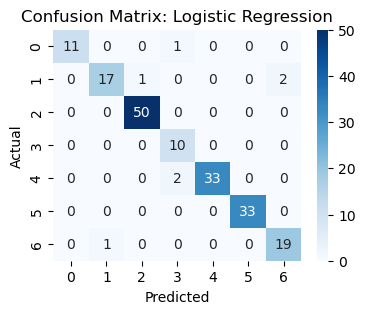

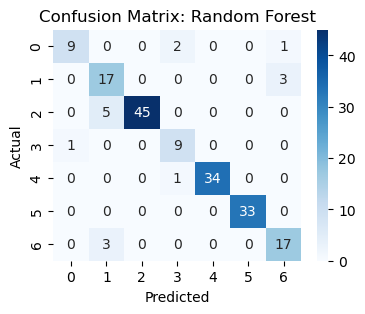

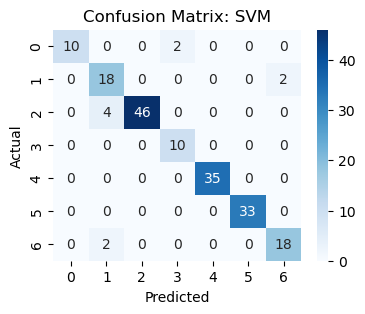

C:\Users\janah\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


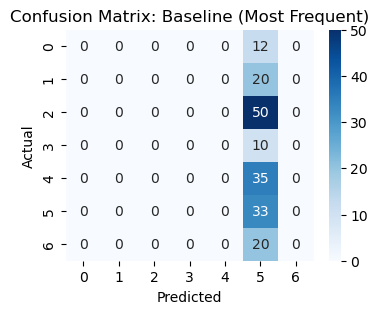

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results = {}

numeric_features = FEATURE_COLS

for name, model in models.items():
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features)],
        remainder='passthrough'
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }
    
   
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Confusion matrices show that Random Forest best balances predictions across all date fruit classes, while the baseline predicts only the most frequent class.

# Model Performance Comparison


In [14]:
results_df = pd.DataFrame(results)
print("\n=== Model Performance Comparison ===")
results_df



=== Model Performance Comparison ===


,Logistic Regression,Random Forest,SVM,Baseline (Most Frequent)
Accuracy,0.961111,0.911111,0.944444,0.183333
Precision,0.964978,0.922725,0.951852,0.033611
Recall,0.961111,0.911111,0.944444,0.183333
F1 Score,0.961560,0.914209,0.946002,0.056808



Model comparison confirms that Random Forest outperforms Logistic Regression, SVM, and the baseline in overall accuracy and F1 score.